# 03 - Modelo final y artifacts de competencia

Entrena el modelo final con la configuración ganadora de
`02_experiments.ipynb` (`iter7_remove_outliers`: MLP (128, 64) + dropout 0.2
+ batchnorm, target `log1p` estandarizado, weight decay 1e-4, outliers de
`GrLivArea` removidos), guarda los artifacts necesarios para predecir el día
de la competencia, y valida el pipeline completo (`src/predict.py`) contra un
held-out simulado que el modelo final nunca vio durante el entrenamiento.

In [1]:
import sys, json
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
from sklearn.model_selection import train_test_split

from preprocessing import prepare_raw, build_preprocessor, ID_COL, TARGET
from dataset import make_loader
from model import MLP
from engine import fit
from target_transform import fit_target_transform, apply_target_transform, inverse_transform_target

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

WINNING_CONFIG = dict(
    hidden_sizes=(128, 64),
    dropout=0.2,
    batchnorm=True,
    log_target=True,
    scale_target=True,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=32,
)
WINNING_CONFIG

{'hidden_sizes': (128, 64),
 'dropout': 0.2,
 'batchnorm': True,
 'log_target': True,
 'scale_target': True,
 'lr': 0.001,
 'weight_decay': 0.0001,
 'batch_size': 32}

## 1. Separar un held-out simulado (nunca se usa para entrenar)

Se aparta un 15% del dataset como sustituto del dataset held-out que el curso
entregará el día de la competencia — sirve únicamente para reportar un RMSE
final honesto y para validar que `src/predict.py` reproduce exactamente lo
que se calcula acá.

In [2]:
df = pd.read_csv("../data/train.csv")

outlier_mask = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000)
df = df[~outlier_mask].reset_index(drop=True)

train_pool, holdout_sim = train_test_split(df, test_size=0.15, random_state=123)
train_pool = train_pool.reset_index(drop=True)
holdout_sim = holdout_sim.reset_index(drop=True)

holdout_sim.to_csv("../data/holdout_simulated.csv", index=False)
print("train_pool:", train_pool.shape, " holdout_sim:", holdout_sim.shape)

train_pool: (991, 81)  holdout_sim: (175, 81)


## 2. Determinar número de épocas (early stopping) sobre un split interno

Se usa un split adicional 85/15 dentro de `train_pool` solo para decidir
cuántas épocas entrenar, replicando el criterio de early stopping usado en
`02_experiments.ipynb`.

In [3]:
fit_df, val_df = train_test_split(train_pool, test_size=0.15, random_state=42)

clean_fit = prepare_raw(fit_df)
clean_val = prepare_raw(val_df)
pre_probe = build_preprocessor(clean_fit)
X_fit = pre_probe.fit_transform(clean_fit).astype("float32")
X_val = pre_probe.transform(clean_val).astype("float32")

y_fit_raw = fit_df["SalePrice"].values.astype("float32")
y_val_raw = val_df["SalePrice"].values.astype("float32")
y_fit, stats_probe = fit_target_transform(y_fit_raw, log_target=WINNING_CONFIG["log_target"],
                                           scale_target=WINNING_CONFIG["scale_target"])
y_val = apply_target_transform(y_val_raw, stats_probe)

fit_loader = make_loader(X_fit, y_fit, batch_size=WINNING_CONFIG["batch_size"], shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=WINNING_CONFIG["batch_size"], shuffle=False)

torch.manual_seed(42)
probe_model = MLP(input_dim=X_fit.shape[1], hidden_sizes=WINNING_CONFIG["hidden_sizes"],
                   dropout=WINNING_CONFIG["dropout"], batchnorm=WINNING_CONFIG["batchnorm"])
probe_model, probe_history = fit(probe_model, fit_loader, val_loader, epochs=300,
                                  lr=WINNING_CONFIG["lr"], weight_decay=WINNING_CONFIG["weight_decay"],
                                  patience=25, device=DEVICE, verbose=False)

N_EPOCHS = len(probe_history["train_rmse"])
print("Épocas a usar para el entrenamiento final:", N_EPOCHS)

Épocas a usar para el entrenamiento final: 40


## 3. Entrenar el modelo final sobre TODO `train_pool`

Con el número de épocas ya decidido, se reentrena desde cero usando el 100%
de `train_pool` (sin descartar el 15% que antes era validación), para
aprovechar todos los datos disponibles antes de la competencia.

In [4]:
clean_pool = prepare_raw(train_pool)
preprocessor = build_preprocessor(clean_pool)
X_pool = preprocessor.fit_transform(clean_pool).astype("float32")

y_pool_raw = train_pool["SalePrice"].values.astype("float32")
y_pool, target_stats = fit_target_transform(y_pool_raw, log_target=WINNING_CONFIG["log_target"],
                                             scale_target=WINNING_CONFIG["scale_target"])

pool_loader = make_loader(X_pool, y_pool, batch_size=WINNING_CONFIG["batch_size"], shuffle=True)

torch.manual_seed(42)
final_model = MLP(input_dim=X_pool.shape[1], hidden_sizes=WINNING_CONFIG["hidden_sizes"],
                   dropout=WINNING_CONFIG["dropout"], batchnorm=WINNING_CONFIG["batchnorm"])
# val_loader = pool_loader y patience > N_EPOCHS: fuerza a entrenar exactamente N_EPOCHS
# épocas completas sobre el 100% de train_pool (no hay early stopping real aquí,
# el criterio de parada ya se decidió en el paso 2).
final_model, final_history = fit(final_model, pool_loader, pool_loader, epochs=N_EPOCHS,
                                  lr=WINNING_CONFIG["lr"], weight_decay=WINNING_CONFIG["weight_decay"],
                                  patience=N_EPOCHS + 1, device=DEVICE, verbose=False)
print("Entrenamiento final completo.")

Entrenamiento final completo.


## 4. Guardar artifacts (`artifacts/`)

In [5]:
import pathlib
ARTIFACTS_DIR = pathlib.Path("../artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

joblib.dump(preprocessor, ARTIFACTS_DIR / "preprocessor.joblib")
torch.save(final_model.state_dict(), ARTIFACTS_DIR / "model.pt")

config = {
    "input_dim": X_pool.shape[1],
    "hidden_sizes": list(WINNING_CONFIG["hidden_sizes"]),
    "dropout": WINNING_CONFIG["dropout"],
    "batchnorm": WINNING_CONFIG["batchnorm"],
    **target_stats,  # log_target, scale_target, mean, std
}
(ARTIFACTS_DIR / "config.json").write_text(json.dumps(config, indent=2))
config

{'input_dim': 237,
 'hidden_sizes': [128, 64],
 'dropout': 0.2,
 'batchnorm': True,
 'log_target': True,
 'scale_target': True,
 'mean': 12.031723976135254,
 'std': 0.3860834538936615}

## 5. Evaluar sobre el held-out simulado

Este es el número que se reporta como desempeño final en la sección 2.5 del
informe (con la salvedad de que el held-out real de competencia es otro
dataset, entregado el día de la presentación).

In [6]:
final_model.eval()
clean_holdout = prepare_raw(holdout_sim)
X_holdout = preprocessor.transform(clean_holdout).astype("float32")
y_holdout_raw = holdout_sim["SalePrice"].values.astype("float32")

with torch.no_grad():
    raw_preds = final_model(torch.as_tensor(X_holdout, dtype=torch.float32).to(DEVICE)).cpu().numpy().ravel()
holdout_preds = inverse_transform_target(raw_preds, target_stats)

holdout_rmse = float(np.sqrt(np.mean((holdout_preds - y_holdout_raw) ** 2)))
print(f"RMSE en held-out simulado: {holdout_rmse:,.2f}")

RMSE en held-out simulado: 18,264.76


## 6. Análisis de errores (para la sección 2.4 del informe)

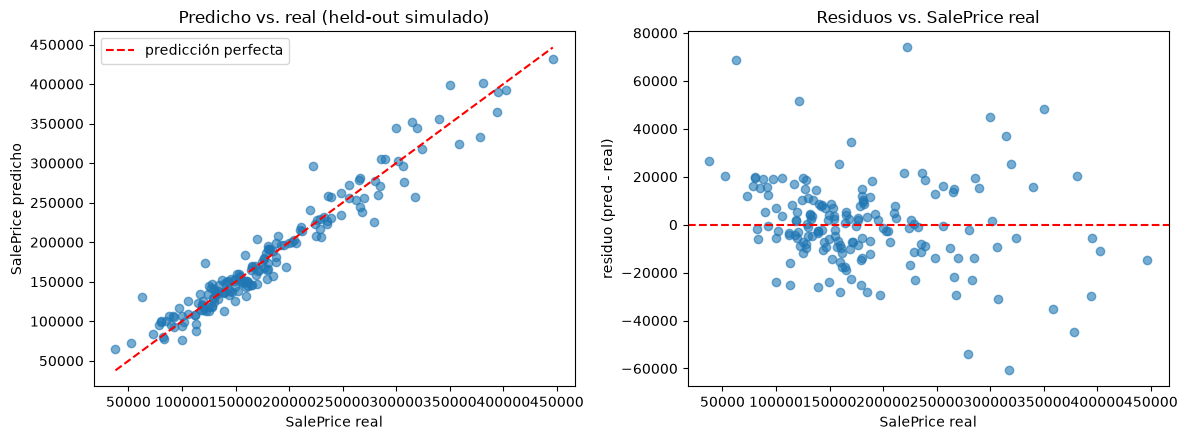

In [7]:
residuals = holdout_preds - y_holdout_raw

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_holdout_raw, holdout_preds, alpha=0.6)
lims = [y_holdout_raw.min(), y_holdout_raw.max()]
axes[0].plot(lims, lims, "r--", label="predicción perfecta")
axes[0].set_xlabel("SalePrice real")
axes[0].set_ylabel("SalePrice predicho")
axes[0].set_title("Predicho vs. real (held-out simulado)")
axes[0].legend()

axes[1].scatter(y_holdout_raw, residuals, alpha=0.6)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("SalePrice real")
axes[1].set_ylabel("residuo (pred - real)")
axes[1].set_title("Residuos vs. SalePrice real")
plt.tight_layout()
plt.show()

In [8]:
errors_df = holdout_sim[["Id", "Neighborhood", "OverallQual", "GrLivArea", "SalePrice"]].copy()
errors_df["pred"] = holdout_preds
errors_df["abs_error"] = (errors_df["pred"] - errors_df["SalePrice"]).abs()
errors_df.sort_values("abs_error", ascending=False).head(10)

,Id,Neighborhood,OverallQual,GrLivArea,SalePrice,pred,abs_error
168,413,Somerst,7,1478,222000,295934.156250,73934.156250
134,463,Sawyer,5,864,62383,130990.093750,68607.093750
88,239,NridgHt,8,1694,318000,257225.718750,60774.281250
49,14,CollgCr,7,1494,279500,225628.953125,53871.046875
99,561,Sawyer,5,1392,121500,173207.296875,51707.296875
67,655,NoRidge,8,2113,350000,398469.437500,48469.437500
174,746,NWAmes,8,2715,299800,344928.656250,45128.656250
6,1268,Timber,9,2018,378500,333569.156250,44930.843750
101,541,Timber,9,1838,315000,351841.156250,36841.156250
26,609,Crawfor,8,3194,359100,323853.093750,35246.906250


Si los residuos crecen en magnitud para casas caras (heterocedasticidad) o
se concentran en algún `Neighborhood`/`OverallQual` particular, es evidencia
de sesgo del modelo a documentar en la discusión (sección 2.4).

## 7. Verificar `src/predict.py` de punta a punta

Se corre el script tal como se usaría el día de la competencia, apuntando al
held-out simulado (que incluye `SalePrice`, así que el script también imprime
el RMSE) y se confirma que coincide con el calculado arriba.

In [9]:
!python ../src/predict.py --input ../data/holdout_simulated.csv --output ../data/holdout_predictions.csv

Predicciones guardadas en ../data/holdout_predictions.csv
RMSE vs. SalePrice real: 18264.76


In [10]:
check = pd.read_csv("../data/holdout_predictions.csv")
recomputed_rmse = float(np.sqrt(np.mean((check["SalePrice"].values - y_holdout_raw) ** 2)))
print(f"RMSE recalculado desde predict.py: {recomputed_rmse:,.2f}")
# predict.py corre en CPU y este notebook entrenó/predijo en DEVICE (puede ser GPU);
# se tolera una diferencia relativa mínima por precisión de punto flotante entre
# CPU y GPU, no por un error del pipeline.
rel_diff = abs(recomputed_rmse - holdout_rmse) / holdout_rmse
print(f"Diferencia relativa vs. el RMSE calculado en el notebook: {rel_diff:.2%}")
assert rel_diff < 1e-3, "El script predict.py no reproduce el mismo resultado"
print("OK: predict.py reproduce el mismo resultado (dentro de precisión de punto flotante CPU/GPU).")

RMSE recalculado desde predict.py: 18,264.76
Diferencia relativa vs. el RMSE calculado en el notebook: 0.00%
OK: predict.py reproduce el mismo resultado (dentro de precisión de punto flotante CPU/GPU).


## Resumen

- **RMSE final (held-out simulado):** ver celda de la sección 5.
- Artifacts guardados en `artifacts/`: `preprocessor.joblib`, `model.pt`,
  `config.json`.
- `src/predict.py --input <csv> --output predictions.csv` está listo para el
  dataset held-out real del día de la competencia.